Variações de arquiteturas:

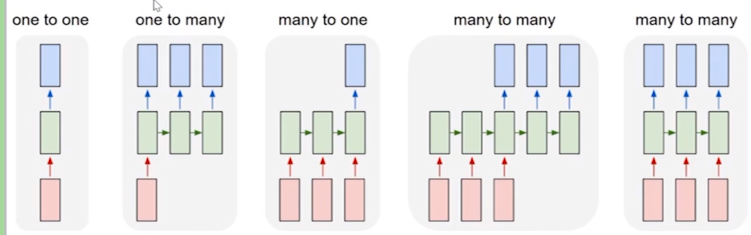

Funções de ativação decidem importância de cada tempo:

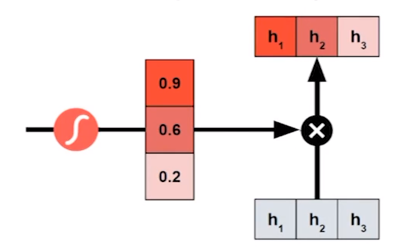

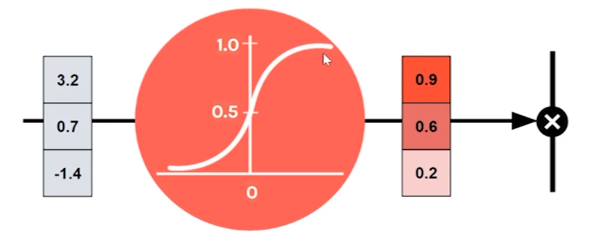

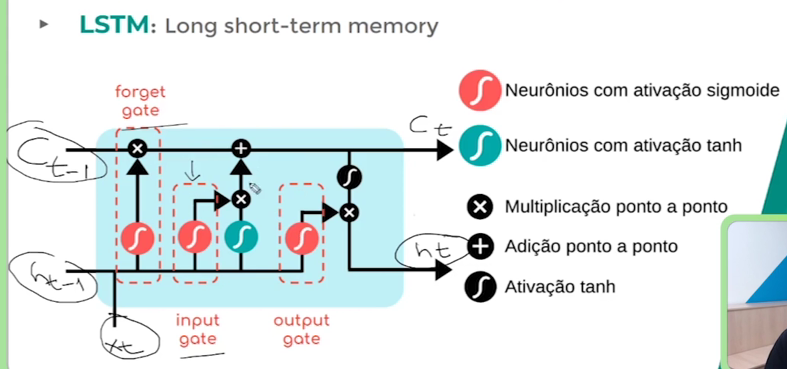

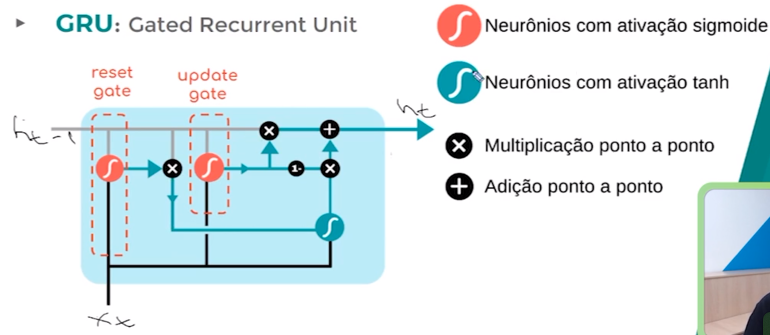

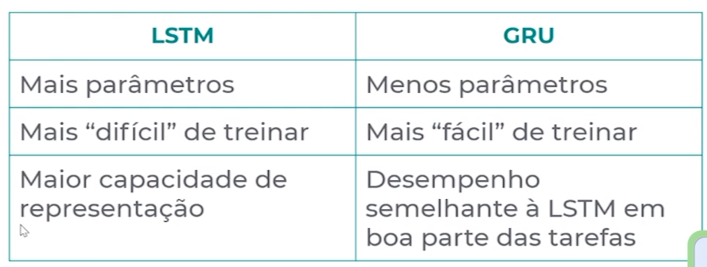

In [22]:
import unicodedata
import string
import sys, random, os
from collections import Counter
import torch
from torch import nn
import numpy as np
import seaborn as sns
sns.set_style('darkgrid')
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
args = {
    'lr': 5e-5,
    'regularizacao': 1e-7,
    'num_epocas': 40,
}
args['device'] = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [3]:
!wget https://download.pytorch.org/tutorial/data.zip #
!unzip data.zip

--2025-04-01 09:28:45--  https://download.pytorch.org/tutorial/data.zip
Resolving download.pytorch.org (download.pytorch.org)... 99.86.38.96, 99.86.38.37, 99.86.38.72, ...
Connecting to download.pytorch.org (download.pytorch.org)|99.86.38.96|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2882130 (2.7M) [application/zip]
Saving to: ‘data.zip’

data.zip            100%[===================>]   2.75M  --.-KB/s    in 0.06s   

2025-04-01 09:28:45 (49.4 MB/s) - ‘data.zip’ saved [2882130/2882130]

Archive:  data.zip
   creating: data/
  inflating: data/eng-fra.txt        
   creating: data/names/
  inflating: data/names/Arabic.txt   
  inflating: data/names/Chinese.txt  
  inflating: data/names/Czech.txt    
  inflating: data/names/Dutch.txt    
  inflating: data/names/English.txt  
  inflating: data/names/French.txt   
  inflating: data/names/German.txt   
  inflating: data/names/Greek.txt    
  inflating: data/names/Irish.txt    
  inflating: data/names/Italian.tx

In [21]:
def le_arquivos(filename):
    lines     = open(filename).read().strip().split('\n')
    nomes     = [unicodedata.normalize('NFKD', line).encode('ascii', 'ignore') for line in lines]
    categoria = filename.split('/')[-1].split('.')[0]
    rotulos   = np.repeat( categoria, len(nomes) )

    return nomes, rotulos


root = 'data/names/'
arquivos = sorted(os.listdir(root))
categorias = [a[:-4] for a in arquivos]

dados, rotulos = [], []
samples_perclass = []

for file_name in arquivos:
  retorno = le_arquivos(os.path.join(root,file_name))
  dados.append(retorno[0])
  rotulos.append(retorno[1])
  samples_perclass.append( (file_name, len(retorno[0])) )

print(samples_perclass, )
print('Minimo amostras', min(samples_perclass, key= lambda k: k[1]), '\n' )
print(dados[categorias.index('Portuguese')][0:10])
print(rotulos[categorias.index('Portuguese')][0:10])

[('Arabic.txt', 2000), ('Chinese.txt', 268), ('Czech.txt', 519), ('Dutch.txt', 297), ('English.txt', 3668), ('French.txt', 277), ('German.txt', 724), ('Greek.txt', 203), ('Irish.txt', 232), ('Italian.txt', 709), ('Japanese.txt', 991), ('Korean.txt', 94), ('Polish.txt', 139), ('Portuguese.txt', 74), ('Russian.txt', 9408), ('Scottish.txt', 100), ('Spanish.txt', 298), ('Vietnamese.txt', 73)]
Minimo amostras ('Vietnamese.txt', 73) 

[b'Abreu', b'Albuquerque', b'Almeida', b'Alves', b'Araujo', b'Araullo', b'Barros', b'Basurto', b'Belo', b'Cabral']
['Portuguese' 'Portuguese' 'Portuguese' 'Portuguese' 'Portuguese'
 'Portuguese' 'Portuguese' 'Portuguese' 'Portuguese' 'Portuguese']


## **Convertendo os rótulos e nomes para tensor**

Representação One-Hot de 18 categorias de idiomas que queremos prever.

In [24]:
def label2tensor(rotulos):
  rotulos_tns = torch.zeros( len(rotulos), 1, dtype=torch.int64 )
  for k, rotulo in enumerate(rotulos):
    idx = categorias.index(rotulo)
    rotulos_tns[k][0] = idx
  return rotulos_tns

rotulos_arabe = rotulos[0]
rotulos_tns = label2tensor(rotulos_arabe)
print(type(rotulos_tns), rotulos_arabe[0], rotulos_tns[0])

<class 'torch.Tensor'> Arabic tensor([0])


In [20]:
caracteres_validos = string.ascii_letters + "-"
print(caracteres_validos)
tam_dicionario = len(caracteres_validos)

def nome2tensor(nome):
  tns = torch.zeros( len(nome), tam_dicionario )
  for k, letra in enumerate(nome.decode('utf-8')):
    idx = caracteres_validos.find(letra)
    tns[k, idx] = 1

  return tns

dados_arabe = dados[0]
dados_tns = [nome2tensor(dado) for dado in dados_arabe]
print(dados_arabe[0].decode('utf-8')[0],'\n', dados_tns[0][0])
print()
print(dados[0][11], nome2tensor(dados[0][11]))

abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZ-
K 
 tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

b'Attia' tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 

## Balanceando batch

In [26]:
num_amostras = min(samples_perclass, key= lambda k: k[1])[1]

def sample_batch(size=num_amostras):
  dados_batch, rotulos_batch = [], []

  for cat in categorias:
    amostras_cat = dados[categorias.index(cat)]
    idx = np.random.choice(range(len(amostras_cat)), size=size, replace=False)

    dados_batch.extend([r for k, r in enumerate(amostras_cat) if k in idx])
    rotulos_batch.extend([cat] * size)

  contagem = Counter(rotulos_batch)
  #print("Distribuição de rótulos no batch:", contagem)

  dados_tns = [nome2tensor(dado) for dado in dados_batch]
  return dados_tns, label2tensor(rotulos_batch)

dados_batch, rotulos_batch = sample_batch()
print(len(dados_batch), dados_batch[0].size(), rotulos_batch.size())


1314 torch.Size([5, 53]) torch.Size([1314, 1])


## Implementando GRU

**B** o tamanho do batch, **S** o comprimento das sequências, **F** o tamanho da feature/hidden e **L** a quantidade de camadas do modelo.

In [29]:
class RNN(nn.Module):
    def __init__(self, tam_entrada, tam_hidden, tam_saida):
        super(RNN, self).__init__()

        self.tam_entrada = tam_entrada
        self.tam_hidden = tam_hidden
        self.tam_saida   = tam_saida

        self.rnn    = nn.GRU(self.tam_entrada, self.tam_hidden, batch_first=True)
        self.linear = nn.Linear(self.tam_hidden, self.tam_saida)
        self.softmax = nn.LogSoftmax(dim=-1)

    def forward(self, nome):

        # Inicialize o estado interno da RNN
        # B x F -> L x B x F
        batch_size = 1
        hidden = torch.zeros(1, batch_size, self.tam_hidden).to(args['device'])
        # S x B x N ou B x S x N
        # nome.unsqueeze(0) - criando uma dimensão artificial para o batch = 1
        # nome.unsqueeze(0) ou nome.unsqueeze(1) - S x N ou S x 1 x N
        saida, hidden = self.rnn(nome.unsqueeze(0), hidden)
        # print("Saída da GRU:", saida.size())
        saida = self.linear(saida[:, -1])
        # S x B x F ou L x B x F
        saida = self.softmax(saida)
        return saida

tam_hidden = 256
model = RNN(tam_dicionario, tam_hidden , len(categorias))
model.to(args['device'])
print(model)

RNN(
  (rnn): GRU(53, 256, batch_first=True)
  (linear): Linear(in_features=256, out_features=18, bias=True)
  (softmax): LogSoftmax(dim=-1)
)


## RNN Bidirecional

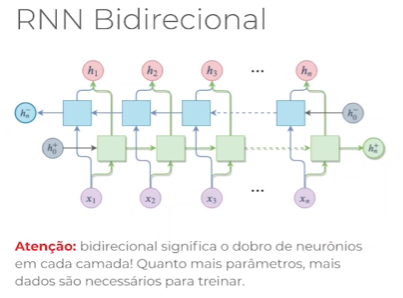

In [ ]:
 criterion = nn.NLLLoss().to(device)
 optimizer = torch.optim.Adam(model.parameters(), lr=args['lr'], weight_decay=args['regularizacao'])

In [ ]:
def forward(X, Y, etapa, epoca):
  if etapa == 'Treino': model.train()
  else: model.eval()
  acuracia = 0.
  loss_epoca = []

  for k, (dado, rotulo) in enumerate(zip(X, Y)):
    dado = dado.to(args['device'])
    rotulo = rotulo.to(args['device'])

    saida = model(dado) # saida = B x C = 1 x 18
    loss = criterion(saida, rotulo)
    loss_epoca.append(loss.detach().cpu().numpy())

    _, pred = torch.max(saida, axis=-1)
    acuracia += 1 if pred[0].item() == rotulo[0].item() else 0

    if etapa == 'Treino':
      # Otimização
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

  loss_epoca = np.asarray(loss_epoca).ravel()
  acuracia   = acuracia/float(len(loss_epoca))
  print('\n','*'*15 + etapa + '*'*15 )
  print('Epoca: {:}, Loss: {:.4f} +/- {:.4f}, Acurácia: {:.4f}'.format(epoca, loss_epoca.mean(),
                                                                        loss_epoca.std(),
                                                                        acuracia*100
                                                                       ))
  return loss_epoca.mean(), acuracia

In [ ]:
loss_treino, loss_test = [], []
acc_treino, acc_test = [], []

dados_test, rotulos_test = sample_batch(size=num_amostras)
for epoch in range(100):

  dados_tns, rotulos_tns = sample_batch()

  loss, acc = forward(dados_tns, rotulos_tns, 'Treino', epoch)
  loss_treino.append(loss)
  acc_treino.append(acc)

  loss, acc = forward(dados_test, rotulos_test, 'Teste', epoch)
  loss_test.append(loss)
  acc_test.append(acc)


In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,3))

ax1.plot(loss_treino[1:], label='Train')
ax1.plot(loss_test[1:], label='Test')
ax1.set_title('Model Convergence - Loss')
ax1.set_xlabel('epochs')
ax1.set_ylabel('Loss')
ax1.legend()

ax2.plot(acc_treino, label='Train')
ax2.plot(acc_test, label='Test')
ax2.set_title('Model Convergence - Accuracy')
ax2.set_xlabel('epochs')
ax2.set_ylabel('Accuracy')
ax2.legend()

In [ ]:
def predict(nome):
  model.eval()

  tns = torch.zeros( len(nome), len(dicionario) )
  for k, letra in enumerate(nome):
    idx = dicionario.find(letra)
    tns[k, idx] = 1
  tns = tns.to(args['device'])

  saida = model(tns)
  #topk pega top 3 predições ao chamar modelo passando o tensor
  topv, topi = saida.data.topk(3, 1, True)

  print(nome)
  for value, index in zip(topv[0], topi[0]):
    print('(%.2f) %s' % (value, categorias[index]))
  print('\n')

predict('Mota')
predict('Kamikaze')
predict('Suarez')

Tensor do nome contém [n1, n2], onde **n1** é quantidade de letras de entrada e **n2** é a quantidade de possíveis letras(tam_dicionario)

## Passos importantes

* Taxonomia dos problemas

Dependendo dos dados utilizados e inferências desejadas, a sua arquitetura recorrente pode tomar as seguintes formas: Many-to-One, One-to-Many, Many-to-Many e Many-to-Many sincronizado. Por exemplo, a análise de sentimentos é um problema Many-to-One.

* Vanishing Gradient

O problema do gradiente que desaparece (ou explode) é especialmente importante para modelos recorrentes, se considerarmos que sequências muito longas produzem um processamento “profundo” no tempo.

* O uso de Gates

Os portões (gates) são parte essencial dos métodos que solucionam o problema do vanishing gradient. Aqui você viu como eles se aplicam a uma feature passando pela célula recorrente.

* LSTM e GRU

Também chamadas de células recorrentes avançadas, a LSTM e a GRU são as principais células capazes de processar longas sequências, mitigando o problema do vanishing gradient.

* RNN no PyTorch

Conhecemos as células RNN, GRU e LSTM no PyTorch, dispensando a implementação de um loop explícito ao processar sequências, como faríamos com as camadas RNNCell, GRUCell e LSTMCell.

* Dimensionalidade dos Dados

Aprendemos a importância do parâmetro batch_first na RNN, diretamente relacionado com a organização do tensor de entrada.

* Implementando a RNN

Substituímos a RNNCell da prática 1 pela GRU para consolidar os conhecimentos teóricos previamente apresentados.

* Deep RNN

Conhecemos a praticidade na construção de uma rede recorrente profunda através do parâmetro num_layers.

* RNN Bidirecional

Conhecemos a praticidade na construção de uma rede recorrente bidirecional através do parâmetro bidirectional. Vimos também o impacto real dessa mudança na arquitetura, bem como seus benefícios em aplicações reais.